# Survey Analysis Notebook

**Project:** Online Trends, Consumer Behavior, and Perceived Platform Control  
**Goal:** Use survey responses to support the paper's mechanism: visible online attention can influence consumer behavior, market perception, and perceived policy/platform response.

This notebook produces report-ready charts and summary tables for:

1. Respondent demographics and media environment
2. Awareness of the four case events
3. Online exposure and perceived visibility
4. Platform control: algorithmic amplification vs moderation/censorship
5. Self-reported consumer behavior change
6. Cross-tab analysis connecting attention/perception to behavior
7. Correlation analysis among Likert-scale variables

**Interpretation rule:** The survey should not be used as causal proof. It is best used as individual-level triangulation that complements Google Trends and case timelines.

In [1]:
# If needed, install packages in your own environment:
# !pip install pandas openpyxl matplotlib seaborn scipy

import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from scipy.stats import spearmanr, chi2_contingency
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# Plot settings
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

OUTPUT_DIR = Path("survey_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Ready. Output folder:", OUTPUT_DIR.resolve())

Ready. Output folder: /Users/leihaotian/Desktop/COMS4419_FInal_Project/survey_outputs


## 1. Load the Excel file

Put the Excel file in the same folder as this notebook, or update `FILE_PATH` below.

In [2]:
FILE_PATH = Path("Online Trends, Consumer Behavior, and Perceived Platform Control（回复）(1).xlsx")

# Fallback: if the file is not in the current folder, search nearby common locations.
if not FILE_PATH.exists():
    candidates = list(Path.cwd().glob("*.xlsx")) + list(Path("/mnt/data").glob("*.xlsx"))
    if candidates:
        print("FILE_PATH not found. Available Excel files:")
        for i, p in enumerate(candidates):
            print(i, p)
        FILE_PATH = candidates[0]
        print("Using:", FILE_PATH)
    else:
        raise FileNotFoundError("No Excel file found. Please update FILE_PATH.")

df_raw = pd.read_excel(FILE_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

FILE_PATH not found. Available Excel files:
0 /Users/leihaotian/Desktop/COMS4419_FInal_Project/Online Trends, Consumer Behavior, and Perceived Platform Control（回复）.xlsx
Using: /Users/leihaotian/Desktop/COMS4419_FInal_Project/Online Trends, Consumer Behavior, and Perceived Platform Control（回复）.xlsx
Shape: (104, 21)


,时间戳记,Which best describes you?,Where do you currently live?,Which media environment are you most familiar with?,How often do you use social media to follow public events or trending topics?,"Before this survey, which of the following events had you heard about?\n(Select all that apply)","For the events you know, where did you first learn about them?",How closely did you follow these events online?,How much discussion about these events did you see online?,"In your opinion, which event became the most visible online?",...,To what extent do you think platform algorithms or trending lists increased the visibility of these events?,"To what extent do you think moderation, censorship, or platform intervention reduced the visibility of these events?",Did online discussion about any of these events affect your own consumption behavior?,"Which type of behavior change did you experience, if any?",Which event do you think had the strongest impact on consumer goods or purchasing behavior?,"How strongly do you agree: “Online trends can create real changes in sales, shortages, or brand reputation.”","How strongly do you agree: “When an online trend becomes large enough in China, the government is likely to respond publicly.”","In your view, what type of response is most likely when a major online controversy grows in China?","Compared with the U.S., how much more control do you think Chinese authorities and platforms have over whether an issue becomes highly visible online?","How strongly do you agree: “Even under stronger government or platform control, some online trends in China still spread widely enough to influence both policy response and consumer behavior.”"
0,2026-04-25 16:37:38.509,Master’s student,United States,Mostly Chinese social media platforms,4,"Urumqi fire (乌鲁木齐大火), Salt panic related to Ja...",Friends / family / classmates,3,4,Nongfu Spring controversy,...,5,4,4,Looked up more information before buying,Salt panic,5,5,Market intervention / supply reassurance,5,4
1,2026-04-28 10:09:23.289,Working professional,Mainland China,Mostly Chinese social media platforms,4,None of the above,Friends / family / classmates,5,5,Urumqi fire,...,2,2,5,Looked up more information before buying,Nongfu Spring controversy,4,4,Platform moderation only,4,4
2,2026-04-28 10:44:02.966,PhD student,United States,Familiar with both about equally,5,"Urumqi fire (乌鲁木齐大火), Salt panic related to Ja...",Traditional news media,3,5,Salt panic,...,5,5,5,Looked up more information before buying,Urumqi fire,5,4,Regulatory or administrative action,4,5
3,2026-04-28 10:45:27.601,Master’s student,Hong Kong / Macau / Taiwan,Mostly Chinese social media platforms,1,"Urumqi fire (乌鲁木齐大火), Nongfu Spring controvers...",Traditional news media,4,5,Nongfu Spring controversy,...,4,5,5,Looked up more information before buying,Urumqi fire,4,5,Market intervention / supply reassurance,4,4
4,2026-04-28 10:50:52.614,Undergraduate student,Mainland China,Mostly Chinese social media platforms,5,Salt panic related to Japan wastewater release...,"Chinese social media (Weibo, Douyin, WeChat, X...",4,3,Not Sure,...,2,5,4,Looked up more information before buying,Nongfu Spring controversy,5,5,Official media statement / clarification,4,4


## 2. Clean and rename columns

The original Google Form column names are long. This cell creates short analytical variable names.

In [3]:
# Remove fully empty rows and clean column names
df = df_raw.dropna(how="all").copy()
df.columns = [str(c).strip() for c in df.columns]

# Rename columns based on the actual survey file
rename_map = {
    "时间戳记": "timestamp",
    "Which best describes you?": "respondent_type",
    "Where do you currently live?": "location",
    "Which media environment are you most familiar with?": "media_environment",
    "How often do you use social media to follow public events or trending topics?": "social_media_frequency",
    "Before this survey, which of the following events had you heard about?\n(Select all that apply)": "events_heard",
    "For the events you know, where did you first learn about them?": "first_source",
    "How closely did you follow these events online?": "follow_closeness",
    "How much discussion about these events did you see online?": "discussion_seen",
    "In your opinion, which event became the most visible online?": "most_visible_event",
    "How quickly do you think these events spread online after the trigger happened?": "spread_speed",
    "To what extent do you think platform algorithms or trending lists increased the visibility of these events?": "algorithm_amplification",
    "To what extent do you think moderation, censorship, or platform intervention reduced the visibility of these events?": "moderation_reduction",
    "Did online discussion about any of these events affect your own consumption behavior?": "behavior_effect",
    "Which type of behavior change did you experience, if any?": "behavior_type",
    "Which event do you think had the strongest impact on consumer goods or purchasing behavior?": "strongest_consumer_event",
    "How strongly do you agree: “Online trends can create real changes in sales, shortages, or brand reputation.”": "agree_market_effect",
    "How strongly do you agree: “When an online trend becomes large enough in China, the government is likely to respond publicly.”": "agree_government_response",
    "In your view, what type of response is most likely when a major online controversy grows in China?": "likely_response_type",
    "Compared with the U.S., how much more control do you think Chinese authorities and platforms have over whether an issue becomes highly visible online?": "china_control_vs_us",
    "How strongly do you agree: “Even under stronger government or platform control, some online trends in China still spread widely enough to influence both policy response and consumer behavior.”": "agree_control_but_spread",
}

df = df.rename(columns=rename_map)

# Convert Likert-like columns to numeric
likert_cols = [
    "social_media_frequency", "follow_closeness", "discussion_seen", "spread_speed",
    "algorithm_amplification", "moderation_reduction", "behavior_effect",
    "agree_market_effect", "agree_government_response", "china_control_vs_us",
    "agree_control_but_spread",
]
for col in likert_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Helpful derived variables
df["behavior_high"] = np.where(df["behavior_effect"] >= 4, "High effect (4-5)", "Low/medium effect (1-3)")
df["attention_high"] = np.where(df["discussion_seen"] >= 4, "High discussion seen (4-5)", "Low/medium discussion (1-3)")
df["platform_control_high"] = np.where(df["china_control_vs_us"] >= 4, "High perceived control (4-5)", "Low/medium perceived control (1-3)")

print("Cleaned shape:", df.shape)
df.head()

Cleaned shape: (104, 24)


,timestamp,respondent_type,location,media_environment,social_media_frequency,events_heard,first_source,follow_closeness,discussion_seen,most_visible_event,...,behavior_type,strongest_consumer_event,agree_market_effect,agree_government_response,likely_response_type,china_control_vs_us,agree_control_but_spread,behavior_high,attention_high,platform_control_high
0,2026-04-25 16:37:38.509,Master’s student,United States,Mostly Chinese social media platforms,4,"Urumqi fire (乌鲁木齐大火), Salt panic related to Ja...",Friends / family / classmates,3,4,Nongfu Spring controversy,...,Looked up more information before buying,Salt panic,5,5,Market intervention / supply reassurance,5,4,High effect (4-5),High discussion seen (4-5),High perceived control (4-5)
1,2026-04-28 10:09:23.289,Working professional,Mainland China,Mostly Chinese social media platforms,4,None of the above,Friends / family / classmates,5,5,Urumqi fire,...,Looked up more information before buying,Nongfu Spring controversy,4,4,Platform moderation only,4,4,High effect (4-5),High discussion seen (4-5),High perceived control (4-5)
2,2026-04-28 10:44:02.966,PhD student,United States,Familiar with both about equally,5,"Urumqi fire (乌鲁木齐大火), Salt panic related to Ja...",Traditional news media,3,5,Salt panic,...,Looked up more information before buying,Urumqi fire,5,4,Regulatory or administrative action,4,5,High effect (4-5),High discussion seen (4-5),High perceived control (4-5)
3,2026-04-28 10:45:27.601,Master’s student,Hong Kong / Macau / Taiwan,Mostly Chinese social media platforms,1,"Urumqi fire (乌鲁木齐大火), Nongfu Spring controvers...",Traditional news media,4,5,Nongfu Spring controversy,...,Looked up more information before buying,Urumqi fire,4,5,Market intervention / supply reassurance,4,4,High effect (4-5),High discussion seen (4-5),High perceived control (4-5)
4,2026-04-28 10:50:52.614,Undergraduate student,Mainland China,Mostly Chinese social media platforms,5,Salt panic related to Japan wastewater release...,"Chinese social media (Weibo, Douyin, WeChat, X...",4,3,Not Sure,...,Looked up more information before buying,Nongfu Spring controversy,5,5,Official media statement / clarification,4,4,High effect (4-5),Low/medium discussion (1-3),High perceived control (4-5)


## 3. Helper functions

These functions standardize plots and save each figure into `survey_outputs/`.

In [4]:
def save_current_fig(filename):
    path = OUTPUT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("Saved:", path)

def count_percent(series, dropna=True):
    counts = series.value_counts(dropna=dropna)
    pct = series.value_counts(normalize=True, dropna=dropna) * 100
    return pd.DataFrame({"count": counts, "percent": pct.round(1)})

def plot_count(series, title, xlabel="", ylabel="Number of respondents", filename=None, order=None, rotate=25):
    data = series.dropna().astype(str)
    plt.figure(figsize=(9, 4.8))
    ax = sns.countplot(y=data, order=order if order is not None else data.value_counts().index)
    ax.set_title(title)
    ax.set_xlabel(ylabel)
    ax.set_ylabel(xlabel)
    for container in ax.containers:
        ax.bar_label(container, fmt="%d", padding=3)
    if filename:
        save_current_fig(filename)
    plt.show()

def plot_likert(col, title, filename=None):
    order = [1, 2, 3, 4, 5]
    counts = df[col].value_counts().reindex(order, fill_value=0)
    pct = counts / counts.sum() * 100
    plt.figure(figsize=(7, 4.5))
    ax = sns.barplot(x=counts.index, y=counts.values)
    ax.set_title(title)
    ax.set_xlabel("Likert score: 1 = low / disagree, 5 = high / agree")
    ax.set_ylabel("Number of respondents")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, f"{v}\n({pct.iloc[i]:.1f}%)", ha="center", va="bottom", fontsize=9)
    if filename:
        save_current_fig(filename)
    plt.show()

def stacked_crosstab(row, col, title, filename=None, normalize=True):
    tab = pd.crosstab(df[row], df[col], normalize="index" if normalize else False)
    if normalize:
        tab = tab * 100
    ax = tab.plot(kind="bar", stacked=True, figsize=(9, 5))
    ax.set_title(title)
    ax.set_xlabel(row)
    ax.set_ylabel("Percent within group" if normalize else "Count")
    ax.legend(title=col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.xticks(rotation=25, ha="right")
    if filename:
        save_current_fig(filename)
    plt.show()
    return tab.round(1)

## 4. Basic survey summary

This gives the sample size and a quick view of missing values.

In [5]:
summary = pd.DataFrame({
    "metric": ["Total responses", "Columns"],
    "value": [len(df), len(df.columns)]
})
display(summary)

missing = df.isna().sum().sort_values(ascending=False).to_frame("missing_count")
missing["missing_percent"] = (missing["missing_count"] / len(df) * 100).round(1)
display(missing.head(10))

summary.to_csv(OUTPUT_DIR / "survey_basic_summary.csv", index=False)

,metric,value
0,Total responses,104
1,Columns,24


,missing_count,missing_percent
location,18,17.3
respondent_type,17,16.3
strongest_consumer_event,1,1.0
timestamp,0,0.0
behavior_effect,0,0.0
attention_high,0,0.0
behavior_high,0,0.0
agree_control_but_spread,0,0.0
china_control_vs_us,0,0.0
likely_response_type,0,0.0


## 5. Demographic breakdown

This directly addresses the TA's feedback: include demographic breakdown in the final report.

,count,percent
respondent_type,,
Undergraduate student,29,33.3
Working professional,27,31.0
Master’s student,20,23.0
PhD student,11,12.6


Saved: survey_outputs/01_respondent_type.png


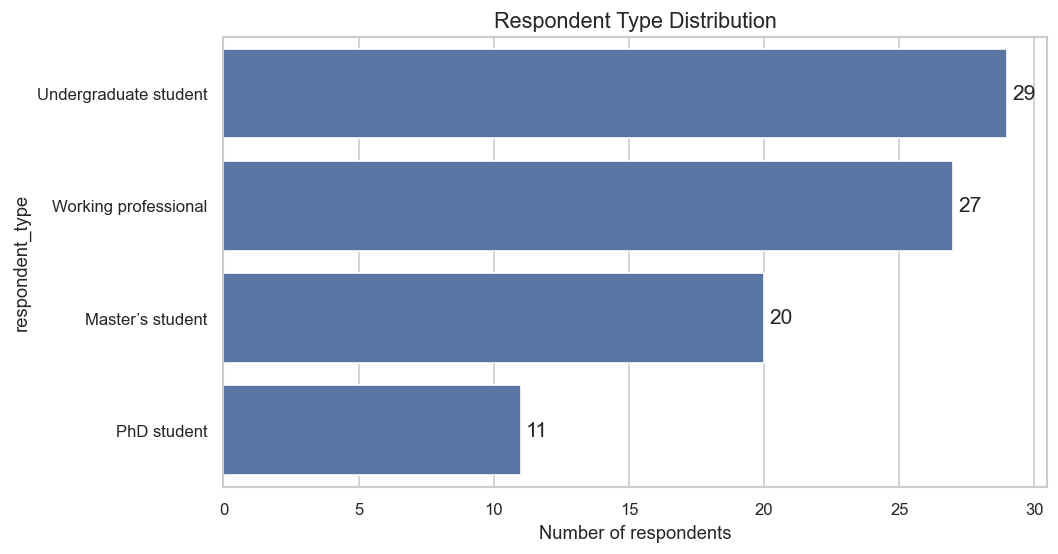

,count,percent
location,,
Mainland China,46,53.5
United States,23,26.7
Hong Kong / Macau / Taiwan,17,19.8


Saved: survey_outputs/02_location.png


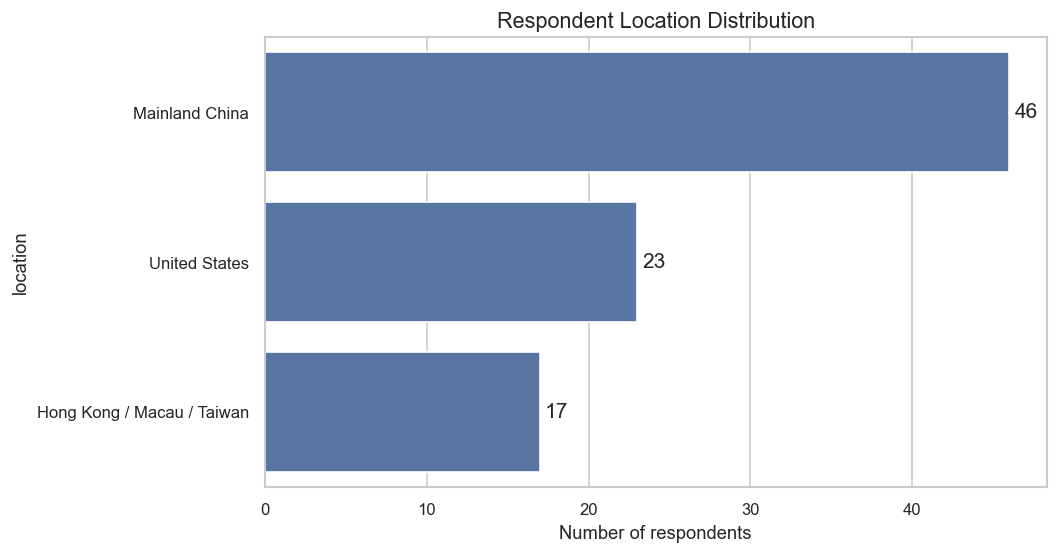

,count,percent
media_environment,,
Mostly Chinese social media platforms,52,50.0
Mostly U.S./Western social media platforms,31,29.8
Familiar with both about equally,21,20.2


Saved: survey_outputs/03_media_environment.png


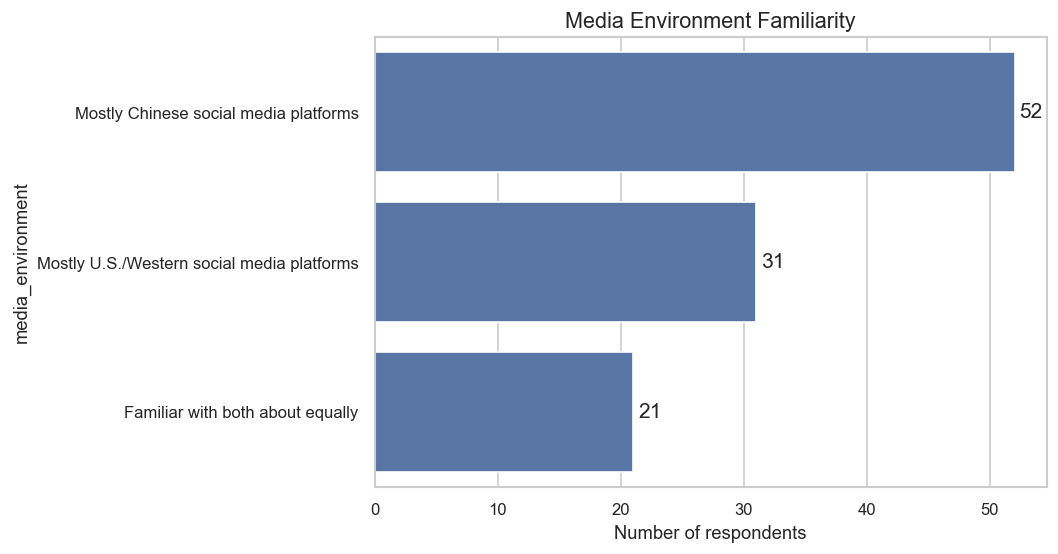

In [6]:
for col, title, fname in [
    ("respondent_type", "Respondent Type Distribution", "01_respondent_type.png"),
    ("location", "Respondent Location Distribution", "02_location.png"),
    ("media_environment", "Media Environment Familiarity", "03_media_environment.png"),
]:
    display(count_percent(df[col]))
    plot_count(df[col], title, xlabel=col, filename=fname)

## 6. Awareness of the four cases

This section turns the multiple-select question into case-level awareness counts. This is useful for showing which examples were actually recognized by respondents.

,event,count,percent_of_respondents
0,Urumqi fire,74,71.2
2,Nongfu Spring,70,67.3
1,Salt panic,66,63.5
3,Lianhua Qingwen,66,63.5
4,None of the above,14,13.5


Saved: survey_outputs/04_event_awareness.png


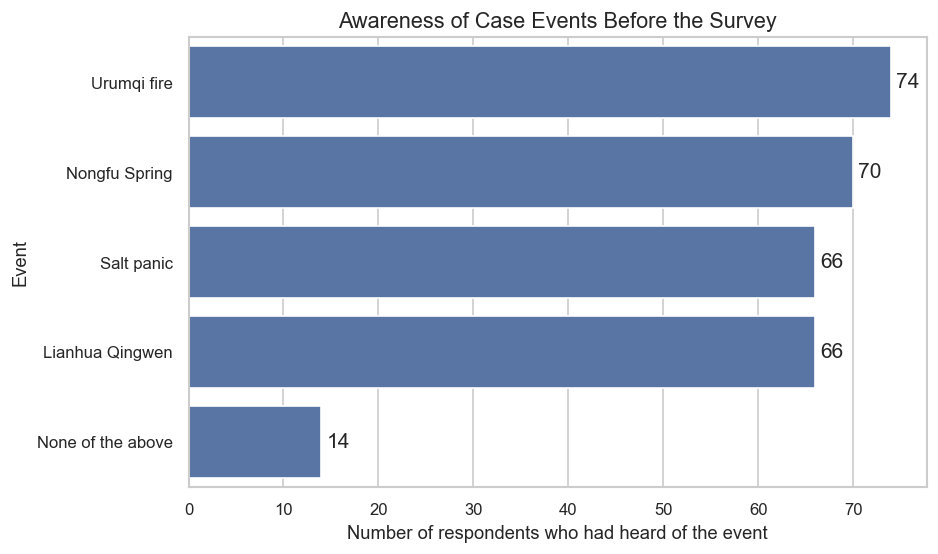

In [7]:
event_map = {
    "Urumqi fire": "Urumqi fire",
    "Salt panic": "Salt panic",
    "Nongfu Spring": "Nongfu Spring",
    "Lianhua Qingwen": "Lianhua Qingwen",
    "None of the above": "None of the above",
}

heard = df["events_heard"].fillna("").astype(str)
for key, label in event_map.items():
    df[f"heard_{label}"] = heard.str.contains(key, case=False, regex=False)

awareness_counts = []
for label in event_map.values():
    c = int(df[f"heard_{label}"].sum())
    awareness_counts.append({"event": label, "count": c, "percent_of_respondents": round(c / len(df) * 100, 1)})
awareness_df = pd.DataFrame(awareness_counts).sort_values("count", ascending=False)
display(awareness_df)
awareness_df.to_csv(OUTPUT_DIR / "event_awareness_counts.csv", index=False)

plt.figure(figsize=(8, 4.8))
ax = sns.barplot(data=awareness_df, y="event", x="count")
ax.set_title("Awareness of Case Events Before the Survey")
ax.set_xlabel("Number of respondents who had heard of the event")
ax.set_ylabel("Event")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)
save_current_fig("04_event_awareness.png")
plt.show()

## 7. Where respondents first learned about the events

This helps distinguish social media, news media, interpersonal exposure, and search behavior.

,count,percent
first_source,,
"Chinese social media (Weibo, Douyin, WeChat, Xiaohongshu, etc.)",40,38.5
"U.S./Western social media (X/Twitter, TikTok, Instagram, Reddit, etc.)",31,29.8
Traditional news media,18,17.3
Friends / family / classmates,15,14.4


Saved: survey_outputs/05_first_source.png


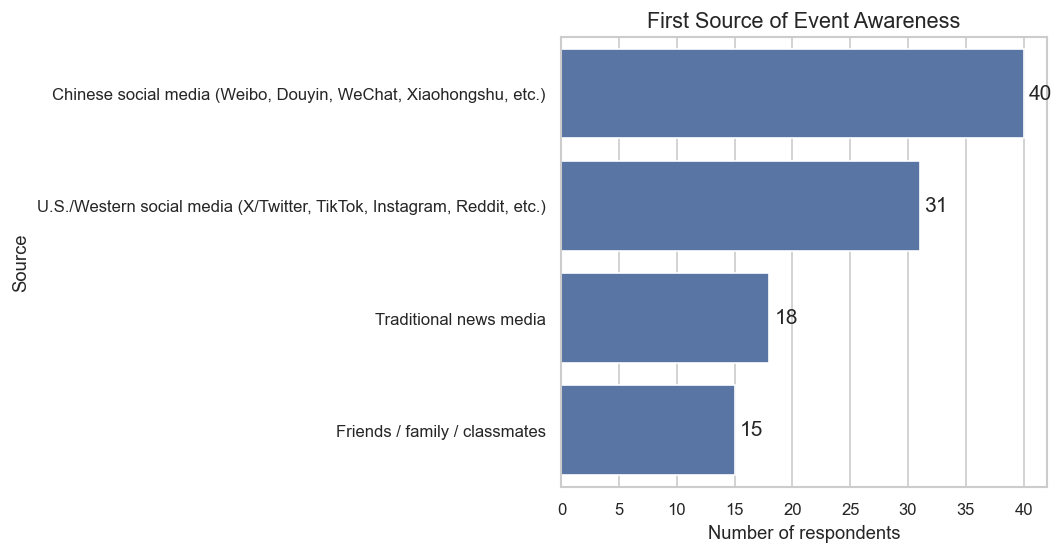

In [8]:
display(count_percent(df["first_source"]))
plot_count(df["first_source"], "First Source of Event Awareness", xlabel="Source", filename="05_first_source.png")

## 8. Online exposure and perceived visibility

These charts measure the attention side of the argument: social media usage, closeness of following, amount of discussion seen, perceived spread speed, and most visible case.

Saved: survey_outputs/06_social_media_frequency.png


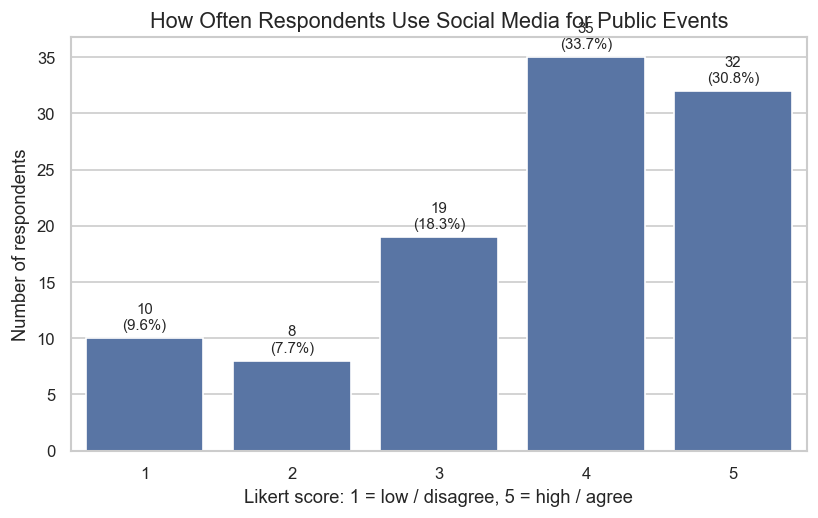

Saved: survey_outputs/07_follow_closeness.png


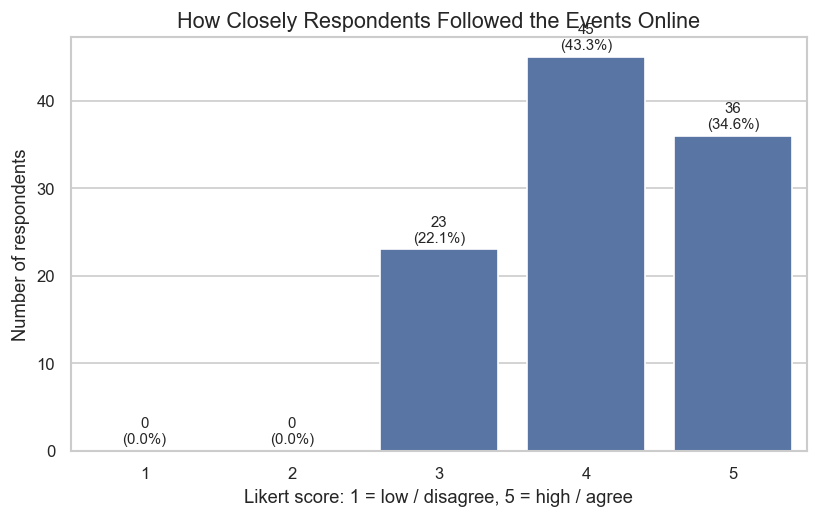

Saved: survey_outputs/08_discussion_seen.png


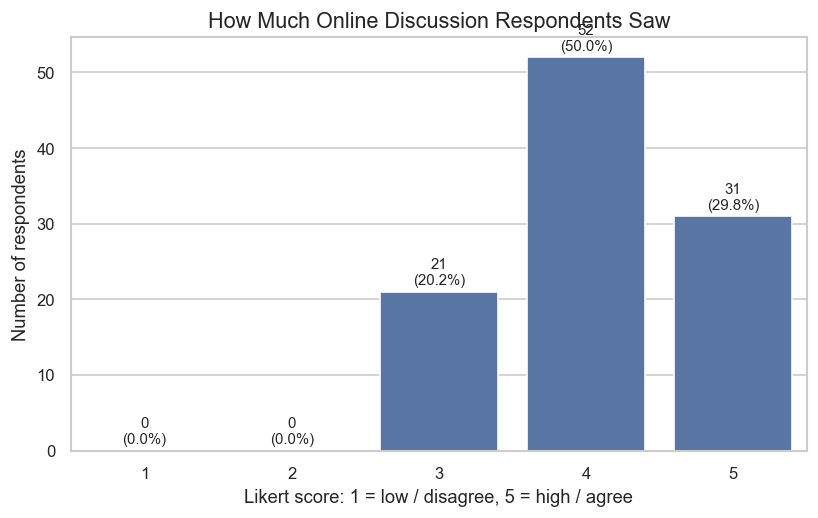

Saved: survey_outputs/09_spread_speed.png


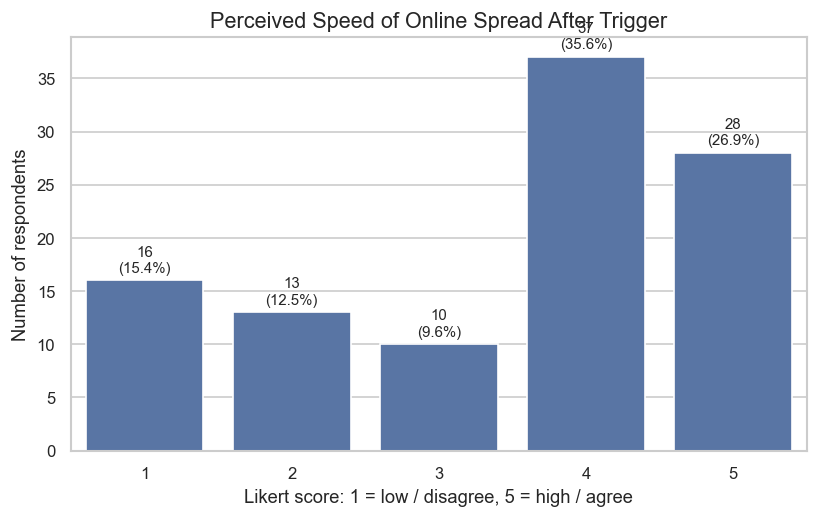

,count,percent
most_visible_event,,
Salt panic,29,27.9
Nongfu Spring controversy,24,23.1
Urumqi fire,24,23.1
Lianhua Qingwen and COVID debate,19,18.3
Not Sure,8,7.7


Saved: survey_outputs/10_most_visible_event.png


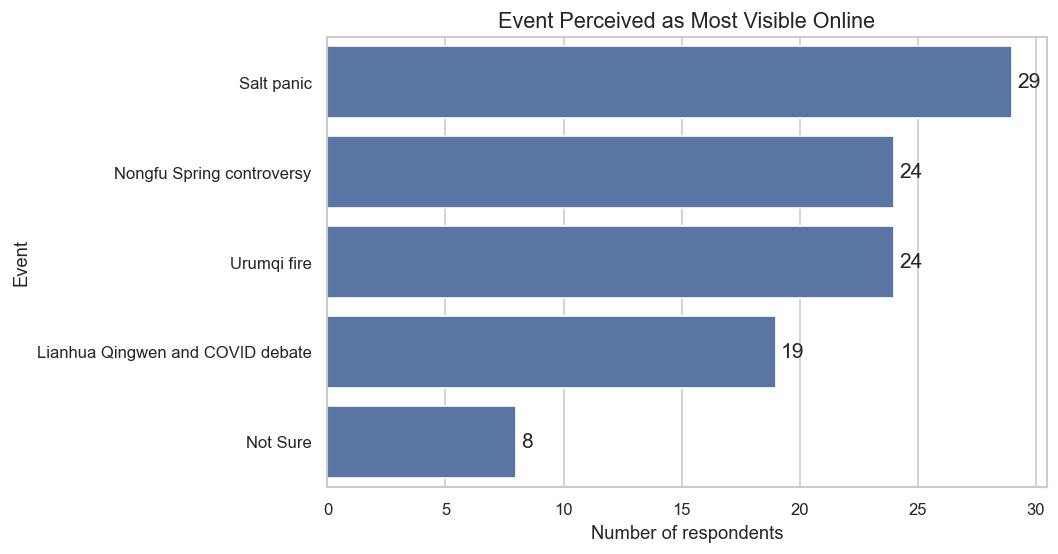

In [9]:
likert_plot_info = [
    ("social_media_frequency", "How Often Respondents Use Social Media for Public Events", "06_social_media_frequency.png"),
    ("follow_closeness", "How Closely Respondents Followed the Events Online", "07_follow_closeness.png"),
    ("discussion_seen", "How Much Online Discussion Respondents Saw", "08_discussion_seen.png"),
    ("spread_speed", "Perceived Speed of Online Spread After Trigger", "09_spread_speed.png"),
]

for col, title, fname in likert_plot_info:
    plot_likert(col, title, fname)

display(count_percent(df["most_visible_event"]))
plot_count(df["most_visible_event"], "Event Perceived as Most Visible Online", xlabel="Event", filename="10_most_visible_event.png")

## 9. Platform control: amplification and reduction

This directly responds to the professor's concern about media vs. social media and platform control. The point is not that Google Trends equals Chinese social media; the survey adds respondent perception of algorithms, trending lists, moderation, censorship, and China-U.S. control differences.

Saved: survey_outputs/11_algorithm_amplification.png


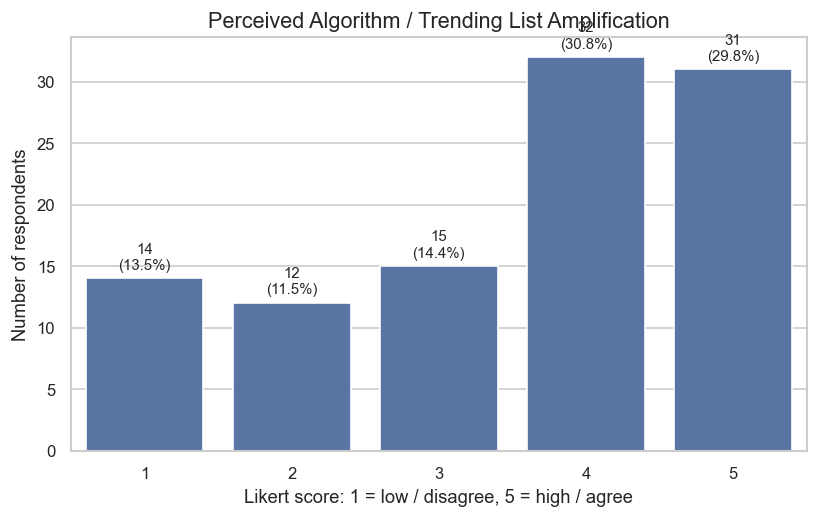

Saved: survey_outputs/12_moderation_reduction.png


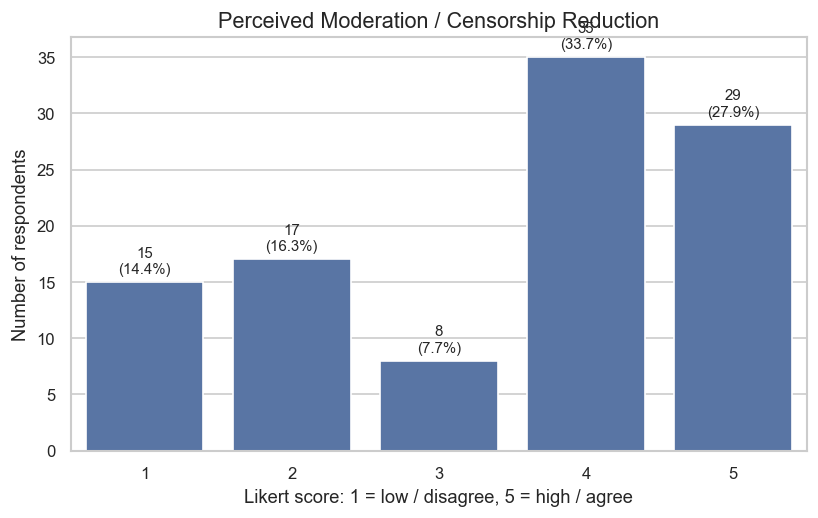

Saved: survey_outputs/13_china_control_vs_us.png


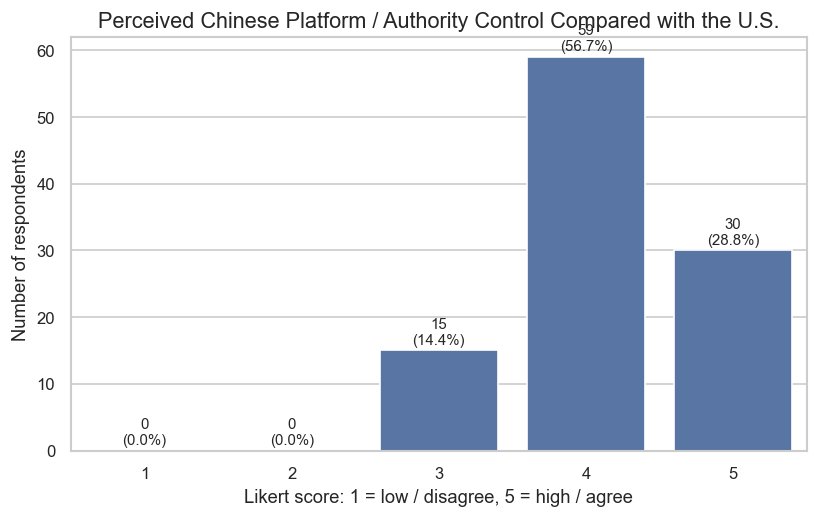

Saved: survey_outputs/14_control_but_spread.png


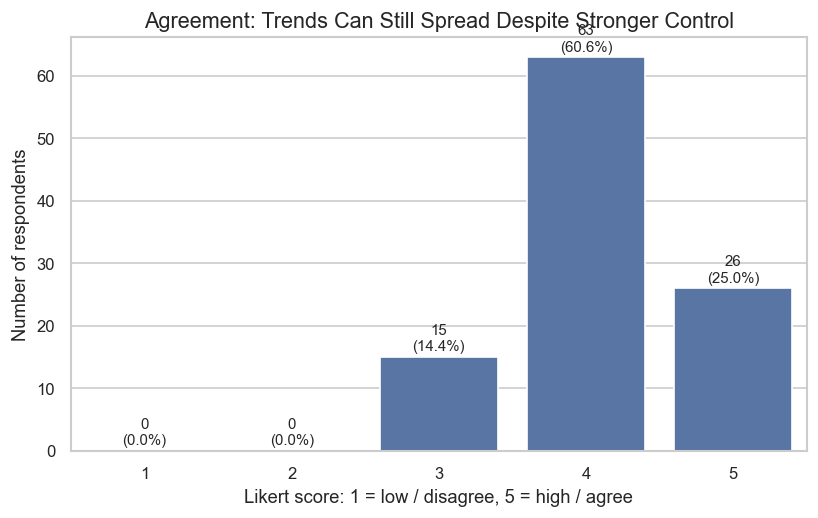

,count,percent
likely_response_type,,
Official media statement / clarification,36,34.6
Market intervention / supply reassurance,27,26.0
Regulatory or administrative action,22,21.2
Platform moderation only,10,9.6
No visible response,9,8.7


Saved: survey_outputs/15_likely_response_type.png


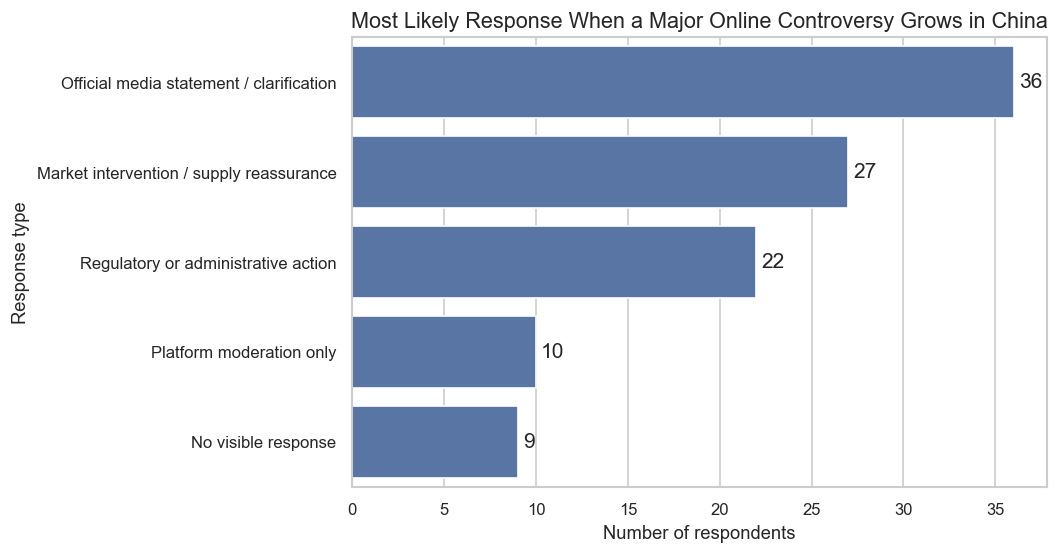

In [10]:
platform_cols = [
    ("algorithm_amplification", "Perceived Algorithm / Trending List Amplification", "11_algorithm_amplification.png"),
    ("moderation_reduction", "Perceived Moderation / Censorship Reduction", "12_moderation_reduction.png"),
    ("china_control_vs_us", "Perceived Chinese Platform / Authority Control Compared with the U.S.", "13_china_control_vs_us.png"),
    ("agree_control_but_spread", "Agreement: Trends Can Still Spread Despite Stronger Control", "14_control_but_spread.png"),
]

for col, title, fname in platform_cols:
    plot_likert(col, title, fname)

display(count_percent(df["likely_response_type"]))
plot_count(df["likely_response_type"], "Most Likely Response When a Major Online Controversy Grows in China", xlabel="Response type", filename="15_likely_response_type.png")

## 10. Consumer behavior and perceived real-world impact

This is the most important survey section for the paper: it connects online discussion to self-reported consumption behavior and perceived market/government consequences.

Saved: survey_outputs/16_behavior_effect.png


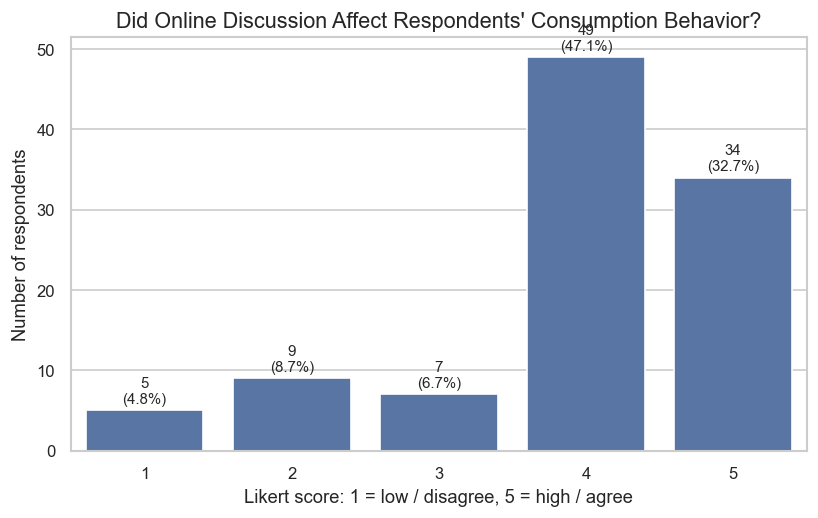

Saved: survey_outputs/17_agree_market_effect.png


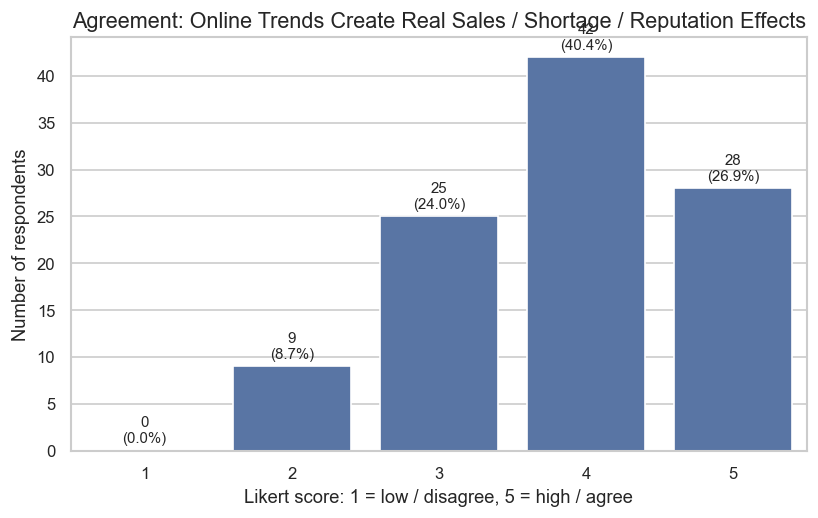

Saved: survey_outputs/18_agree_government_response.png


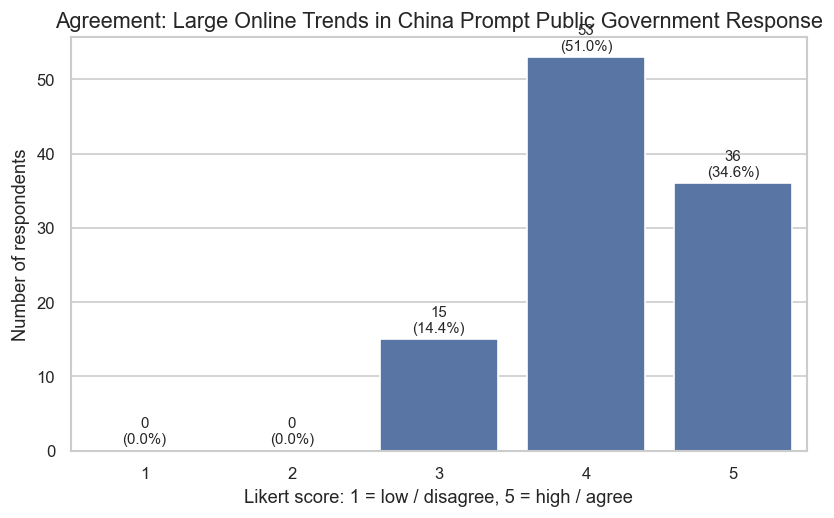

,count,percent
behavior_type,,
Looked up more information before buying,42,40.4
Delayed or avoided a purchase,33,31.7
Switched from one brand/product to another,16,15.4
Bought extra / stocked up on a product,8,7.7
No change,5,4.8


Saved: survey_outputs/19_behavior_type.png


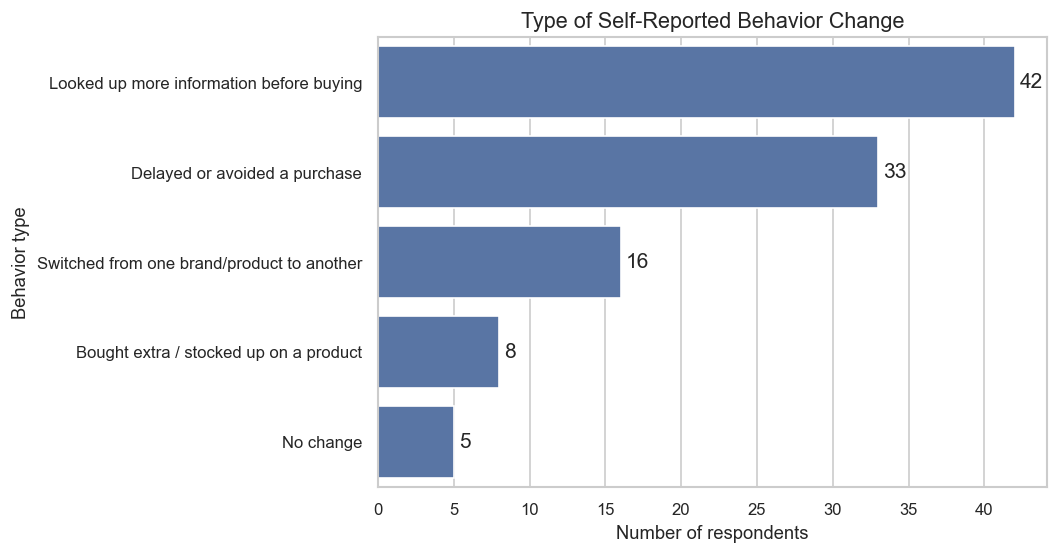

,count,percent
strongest_consumer_event,,
Salt panic,32,31.1
Urumqi fire,29,28.2
Nongfu Spring controversy,25,24.3
Lianhua Qingwen and COVID debate,17,16.5


Saved: survey_outputs/20_strongest_consumer_event.png


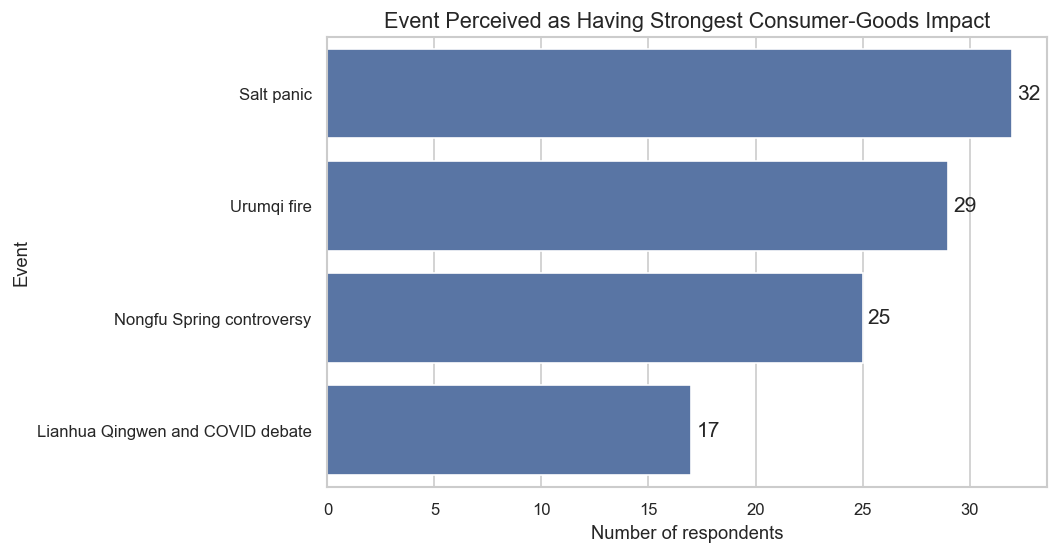

In [11]:
behavior_cols = [
    ("behavior_effect", "Did Online Discussion Affect Respondents' Consumption Behavior?", "16_behavior_effect.png"),
    ("agree_market_effect", "Agreement: Online Trends Create Real Sales / Shortage / Reputation Effects", "17_agree_market_effect.png"),
    ("agree_government_response", "Agreement: Large Online Trends in China Prompt Public Government Response", "18_agree_government_response.png"),
]

for col, title, fname in behavior_cols:
    plot_likert(col, title, fname)

display(count_percent(df["behavior_type"]))
plot_count(df["behavior_type"], "Type of Self-Reported Behavior Change", xlabel="Behavior type", filename="19_behavior_type.png")

display(count_percent(df["strongest_consumer_event"]))
plot_count(df["strongest_consumer_event"], "Event Perceived as Having Strongest Consumer-Goods Impact", xlabel="Event", filename="20_strongest_consumer_event.png")

## 11. Core cross-tab analysis: attention → behavior

These plots are useful for the report because they show whether higher exposure/perceived visibility is associated with stronger self-reported behavior effect.

Saved: survey_outputs/21_attention_vs_behavior.png


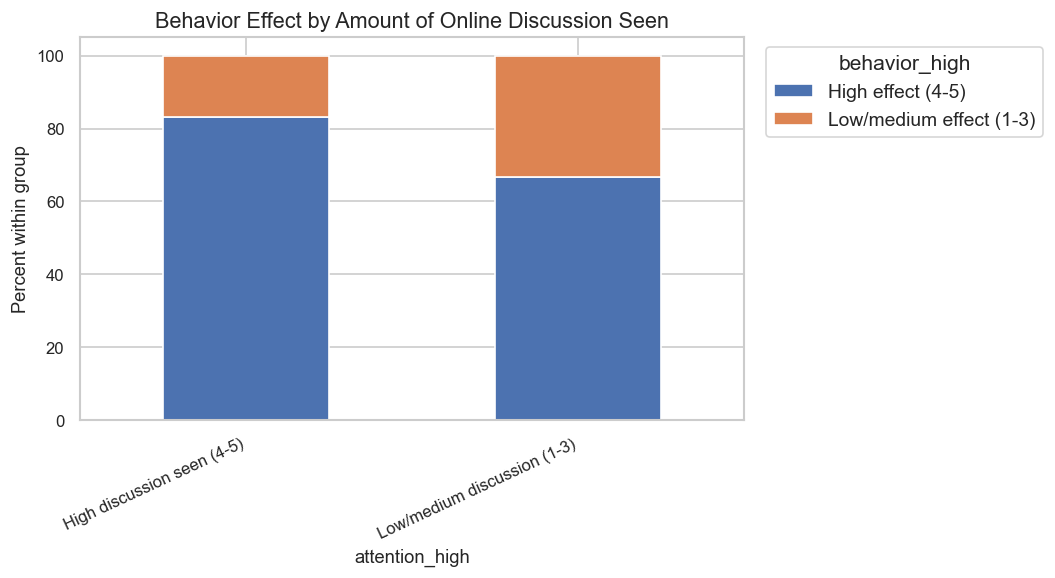

behavior_high,High effect (4-5),Low/medium effect (1-3)
attention_high,,
High discussion seen (4-5),83.1,16.9
Low/medium discussion (1-3),66.7,33.3


Saved: survey_outputs/22_control_vs_behavior.png


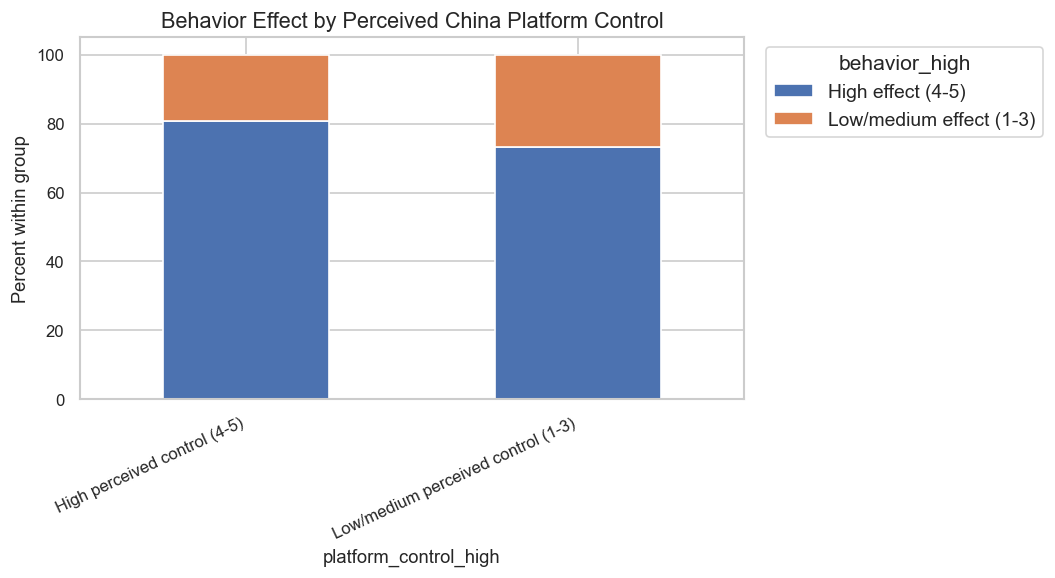

behavior_high,High effect (4-5),Low/medium effect (1-3)
platform_control_high,,
High perceived control (4-5),80.9,19.1
Low/medium perceived control (1-3),73.3,26.7


Saved: survey_outputs/23_media_environment_vs_behavior.png


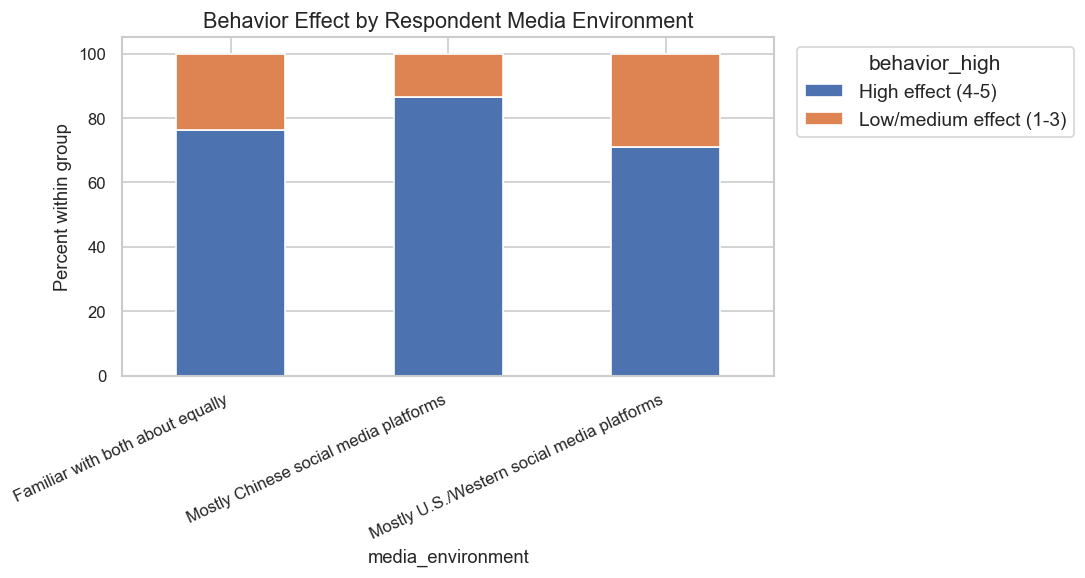

behavior_high,High effect (4-5),Low/medium effect (1-3)
media_environment,,
Familiar with both about equally,76.2,23.8
Mostly Chinese social media platforms,86.5,13.5
Mostly U.S./Western social media platforms,71.0,29.0


In [12]:
tab1 = stacked_crosstab("attention_high", "behavior_high", "Behavior Effect by Amount of Online Discussion Seen", "21_attention_vs_behavior.png")
display(tab1)

tab2 = stacked_crosstab("platform_control_high", "behavior_high", "Behavior Effect by Perceived China Platform Control", "22_control_vs_behavior.png")
display(tab2)

tab3 = stacked_crosstab("media_environment", "behavior_high", "Behavior Effect by Respondent Media Environment", "23_media_environment_vs_behavior.png")
display(tab3)

tab1.to_csv(OUTPUT_DIR / "attention_vs_behavior_crosstab.csv")
tab2.to_csv(OUTPUT_DIR / "control_vs_behavior_crosstab.csv")
tab3.to_csv(OUTPUT_DIR / "media_environment_vs_behavior_crosstab.csv")

## 12. Heatmap: perceived most visible event vs strongest consumer impact

This chart checks whether the event respondents saw as most visible online is also the event they saw as most consequential for consumer goods or purchasing behavior.

strongest_consumer_event,Lianhua Qingwen and COVID debate,Nongfu Spring controversy,Salt panic,Urumqi fire
most_visible_event,,,,
Lianhua Qingwen and COVID debate,3,5,7,3
Nongfu Spring controversy,2,4,8,10
Not Sure,1,1,5,1
Salt panic,5,9,9,6
Urumqi fire,6,6,3,9


Saved: survey_outputs/24_visible_vs_consumer_impact_heatmap.png


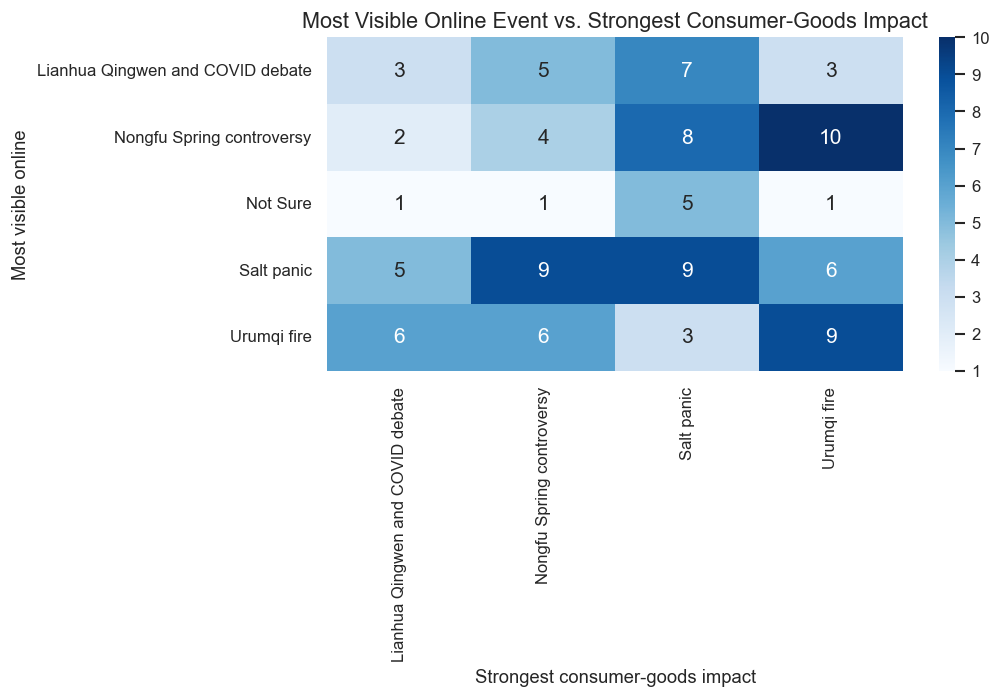

In [13]:
event_heat = pd.crosstab(df["most_visible_event"], df["strongest_consumer_event"])
display(event_heat)

plt.figure(figsize=(9, 6))
sns.heatmap(event_heat, annot=True, fmt="d", cmap="Blues")
plt.title("Most Visible Online Event vs. Strongest Consumer-Goods Impact")
plt.xlabel("Strongest consumer-goods impact")
plt.ylabel("Most visible online")
save_current_fig("24_visible_vs_consumer_impact_heatmap.png")
plt.show()

event_heat.to_csv(OUTPUT_DIR / "visible_vs_consumer_impact_heatmap.csv")

## 13. Likert correlation analysis

This is a compact analytical table. Spearman correlation is appropriate because Likert responses are ordinal. Focus especially on `behavior_effect` and whether it rises with discussion seen, follow closeness, and perceived market impact.

,social_media_frequency,follow_closeness,discussion_seen,spread_speed,algorithm_amplification,moderation_reduction,behavior_effect,agree_market_effect,agree_government_response,china_control_vs_us,agree_control_but_spread
social_media_frequency,1.00,-0.02,-0.07,-0.06,-0.01,-0.05,-0.17,-0.24,-0.04,-0.05,-0.07
follow_closeness,-0.02,1.00,-0.04,-0.05,0.02,0.04,0.12,0.09,-0.04,-0.07,-0.16
discussion_seen,-0.07,-0.04,1.00,0.03,0.01,0.08,0.10,0.15,-0.02,-0.03,0.11
spread_speed,-0.06,-0.05,0.03,1.00,0.69,0.67,-0.00,-0.02,0.05,0.03,0.05
algorithm_amplification,-0.01,0.02,0.01,0.69,1.00,0.75,0.12,0.08,-0.07,-0.04,0.00
moderation_reduction,-0.05,0.04,0.08,0.67,0.75,1.00,0.07,0.18,-0.05,0.03,0.03
behavior_effect,-0.17,0.12,0.10,-0.00,0.12,0.07,1.00,0.50,-0.01,-0.14,-0.01
agree_market_effect,-0.24,0.09,0.15,-0.02,0.08,0.18,0.50,1.00,-0.00,0.07,0.01
agree_government_response,-0.04,-0.04,-0.02,0.05,-0.07,-0.05,-0.01,-0.00,1.00,0.48,0.51
china_control_vs_us,-0.05,-0.07,-0.03,0.03,-0.04,0.03,-0.14,0.07,0.48,1.00,0.51


Saved: survey_outputs/25_likert_spearman_correlation.png


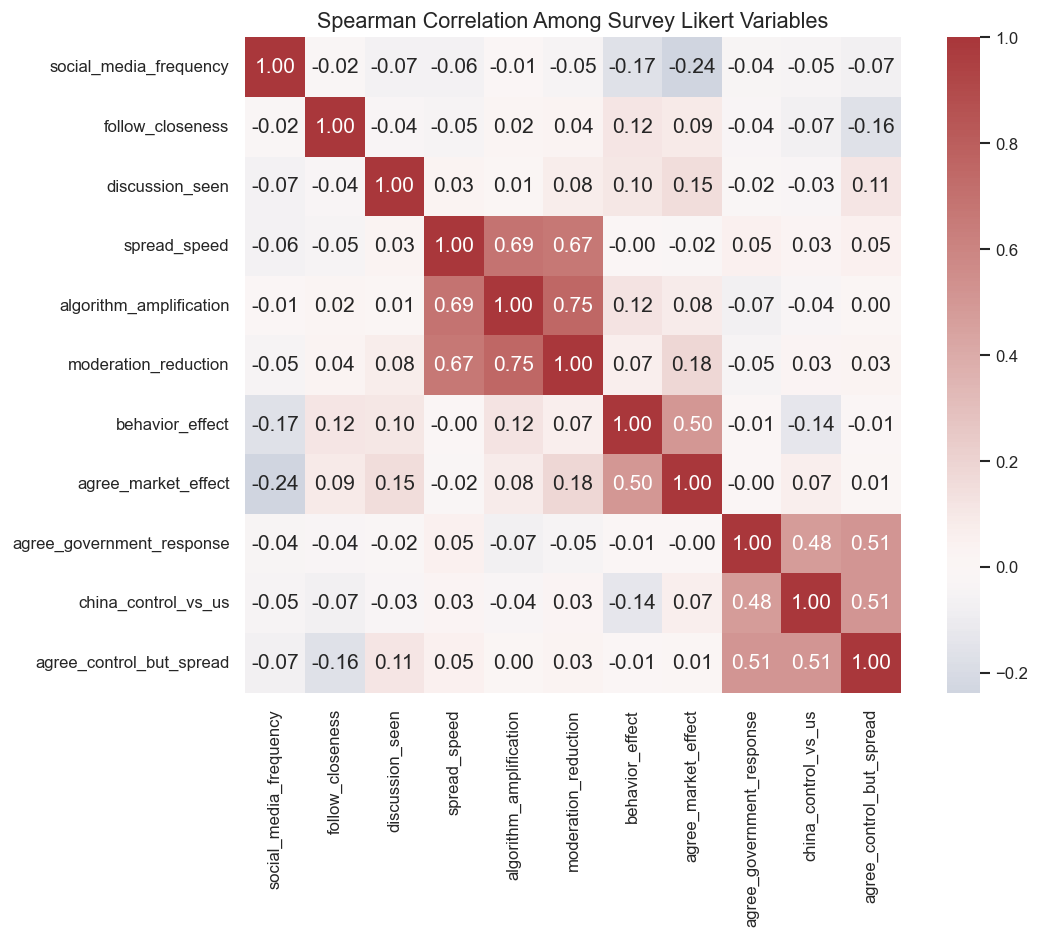

In [14]:
corr_cols = [
    "social_media_frequency", "follow_closeness", "discussion_seen", "spread_speed",
    "algorithm_amplification", "moderation_reduction", "behavior_effect",
    "agree_market_effect", "agree_government_response", "china_control_vs_us",
    "agree_control_but_spread",
]

corr = df[corr_cols].corr(method="spearman")
display(corr.round(2))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Spearman Correlation Among Survey Likert Variables")
save_current_fig("25_likert_spearman_correlation.png")
plt.show()

corr.to_csv(OUTPUT_DIR / "likert_spearman_correlation.csv")

## 14. Focused correlation table for the paper

This table is easier to write about than the full heatmap.

In [15]:
focus_vars = [
    "social_media_frequency",
    "follow_closeness",
    "discussion_seen",
    "spread_speed",
    "algorithm_amplification",
    "moderation_reduction",
    "agree_market_effect",
    "agree_government_response",
    "china_control_vs_us",
    "agree_control_but_spread",
]

rows = []
for var in focus_vars:
    temp = df[[var, "behavior_effect"]].dropna()
    if len(temp) < 3:
        continue
    if SCIPY_AVAILABLE:
        rho, p = spearmanr(temp[var], temp["behavior_effect"])
    else:
        rho, p = temp[var].corr(temp["behavior_effect"], method="spearman"), np.nan
    rows.append({
        "variable": var,
        "spearman_rho_with_behavior_effect": round(float(rho), 3),
        "p_value": round(float(p), 4) if not pd.isna(p) else np.nan,
        "n": len(temp)
    })

focus_corr = pd.DataFrame(rows).sort_values("spearman_rho_with_behavior_effect", ascending=False)
display(focus_corr)
focus_corr.to_csv(OUTPUT_DIR / "focused_behavior_correlations.csv", index=False)

,variable,spearman_rho_with_behavior_effect,p_value,n
6,agree_market_effect,0.498,0.0000,104
4,algorithm_amplification,0.122,0.2156,104
1,follow_closeness,0.118,0.2342,104
2,discussion_seen,0.104,0.2952,104
5,moderation_reduction,0.067,0.5018,104
3,spread_speed,-0.004,0.9639,104
7,agree_government_response,-0.010,0.9182,104
9,agree_control_but_spread,-0.013,0.8935,104
8,china_control_vs_us,-0.137,0.1667,104
0,social_media_frequency,-0.165,0.0941,104


## 15. Optional chi-square tests for categorical relationships

These tests are not necessary for the paper, but they provide a simple check for association between grouped variables. With small cells, interpret cautiously.

In [16]:
if SCIPY_AVAILABLE:
    tests = []
    for row_var, col_var in [
        ("attention_high", "behavior_high"),
        ("platform_control_high", "behavior_high"),
        ("media_environment", "behavior_high"),
    ]:
        table = pd.crosstab(df[row_var], df[col_var])
        chi2, p, dof, expected = chi2_contingency(table)
        tests.append({
            "row_variable": row_var,
            "column_variable": col_var,
            "chi2": round(chi2, 3),
            "p_value": round(p, 4),
            "dof": dof,
            "min_expected_cell": round(expected.min(), 2),
        })
    chi_tests = pd.DataFrame(tests)
    display(chi_tests)
    chi_tests.to_csv(OUTPUT_DIR / "chi_square_tests.csv", index=False)
else:
    print("scipy is not available, so chi-square tests were skipped.")

,row_variable,column_variable,chi2,p_value,dof,min_expected_cell
0,attention_high,behavior_high,1.890,0.1691,1,4.24
1,platform_control_high,behavior_high,0.107,0.7432,1,3.03
2,media_environment,behavior_high,3.136,0.2085,2,4.24


## 16. Report-ready summary numbers

This cell creates a compact table of percentages that can be used directly in the final report or presentation.

In [17]:
def pct_ge(col, threshold=4):
    valid = df[col].dropna()
    return round((valid >= threshold).mean() * 100, 1) if len(valid) else np.nan

def top_category(col):
    vc = df[col].dropna().astype(str).value_counts()
    if vc.empty:
        return None, np.nan
    return vc.index[0], round(vc.iloc[0] / vc.sum() * 100, 1)

top_visible, top_visible_pct = top_category("most_visible_event")
top_consumer, top_consumer_pct = top_category("strongest_consumer_event")
top_response, top_response_pct = top_category("likely_response_type")

report_summary = pd.DataFrame([
    {"finding": "Respondents using social media frequently for public events (4-5)", "value": f"{pct_ge('social_media_frequency')}%"},
    {"finding": "Respondents who saw high online discussion about the events (4-5)", "value": f"{pct_ge('discussion_seen')}%"},
    {"finding": "Respondents reporting high consumption-behavior effect (4-5)", "value": f"{pct_ge('behavior_effect')}%"},
    {"finding": "Respondents agreeing online trends create real market/reputation effects (4-5)", "value": f"{pct_ge('agree_market_effect')}%"},
    {"finding": "Respondents agreeing large Chinese online trends likely trigger public government response (4-5)", "value": f"{pct_ge('agree_government_response')}%"},
    {"finding": "Respondents perceiving stronger Chinese platform/authority control than U.S. (4-5)", "value": f"{pct_ge('china_control_vs_us')}%"},
    {"finding": "Most visible online event", "value": f"{top_visible} ({top_visible_pct}%)"},
    {"finding": "Event perceived as strongest consumer-goods impact", "value": f"{top_consumer} ({top_consumer_pct}%)"},
    {"finding": "Most likely response type in China", "value": f"{top_response} ({top_response_pct}%)"},
])

display(report_summary)
report_summary.to_csv(OUTPUT_DIR / "report_ready_summary_numbers.csv", index=False)

,finding,value
0,Respondents using social media frequently for ...,64.4%
1,Respondents who saw high online discussion abo...,79.8%
2,Respondents reporting high consumption-behavio...,79.8%
3,Respondents agreeing online trends create real...,67.3%
4,Respondents agreeing large Chinese online tren...,85.6%
5,Respondents perceiving stronger Chinese platfo...,85.6%
6,Most visible online event,Salt panic (27.9%)
7,Event perceived as strongest consumer-goods im...,Salt panic (31.1%)
8,Most likely response type in China,Official media statement / clarification (34.6%)


## 17. Suggested interpretation paragraph

You can adapt this paragraph for the final report. Replace the bracketed values after running the notebook if you want exact numbers in prose.

In [18]:
print("Suggested write-up:")
print()
print(f"The survey provides individual-level evidence that complements the case-based and Google Trends analysis. Among {len(df)} respondents, {pct_ge('discussion_seen')}% reported seeing a high level of online discussion about the selected events, and {pct_ge('behavior_effect')}% reported that online discussion had a high effect on their own consumption behavior. Respondents also strongly recognized offline consequences: {pct_ge('agree_market_effect')}% agreed that online trends can create real changes in sales, shortages, or brand reputation, while {pct_ge('agree_government_response')}% agreed that large online trends in China are likely to trigger public government response. These results do not prove causality, but they support the paper’s mechanism that visible online attention can become consequential once it is perceived as large enough by consumers, investors, or regulators.")

Suggested write-up:

The survey provides individual-level evidence that complements the case-based and Google Trends analysis. Among 104 respondents, 79.8% reported seeing a high level of online discussion about the selected events, and 79.8% reported that online discussion had a high effect on their own consumption behavior. Respondents also strongly recognized offline consequences: 67.3% agreed that online trends can create real changes in sales, shortages, or brand reputation, while 85.6% agreed that large online trends in China are likely to trigger public government response. These results do not prove causality, but they support the paper’s mechanism that visible online attention can become consequential once it is perceived as large enough by consumers, investors, or regulators.


## 18. Export cleaned data

This makes the cleaned dataset and all generated charts available in the output folder.

In [19]:
df.to_csv(OUTPUT_DIR / "cleaned_survey_data.csv", index=False)
print("Exported cleaned data and charts to:", OUTPUT_DIR.resolve())
print("Files created:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print("-", p.name)

Exported cleaned data and charts to: /Users/leihaotian/Desktop/COMS4419_FInal_Project/survey_outputs
Files created:
- 01_respondent_type.png
- 02_location.png
- 03_media_environment.png
- 04_event_awareness.png
- 05_first_source.png
- 06_social_media_frequency.png
- 07_follow_closeness.png
- 08_discussion_seen.png
- 09_spread_speed.png
- 10_most_visible_event.png
- 11_algorithm_amplification.png
- 12_moderation_reduction.png
- 13_china_control_vs_us.png
- 14_control_but_spread.png
- 15_likely_response_type.png
- 16_behavior_effect.png
- 17_agree_market_effect.png
- 18_agree_government_response.png
- 19_behavior_type.png
- 20_strongest_consumer_event.png
- 21_attention_vs_behavior.png
- 22_control_vs_behavior.png
- 23_media_environment_vs_behavior.png
- 24_visible_vs_consumer_impact_heatmap.png
- 25_likert_spearman_correlation.png
- attention_vs_behavior_crosstab.csv
- chi_square_tests.csv
- cleaned_survey_data.csv
- control_vs_behavior_crosstab.csv
- event_awareness_counts.csv
- focuse